# Demostración de gradientes desvanecidos

Durante la retropropagación, los gradientes viajan desde la pérdida hacia las primeras capas. Por la regla de la cadena, ese recorrido produce un producto de muchas derivadas. Si muchos factores son menores que uno, el gradiente puede volverse muy pequeño.

$$
\frac{\partial \mathcal{L}}{\partial h_l}
=
\frac{\partial \mathcal{L}}{\partial h_L}
\prod_{k=l+1}^{L}
\frac{\partial h_k}{\partial h_{k-1}}
$$

En este notebook compararemos una CNN profunda con activaciones sigmoid, tanh, ReLU y LeakyReLU.

**Mensaje central:** Los gradientes desvanecidos aparecen por el efecto acumulado de muchas derivadas pequeñas, no por una sola capa.

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

torch.manual_seed(7)
np.random.seed(7)


def build_deep_cnn(activation_name, num_layers=12):
    layers = []
    in_channels = 3
    hidden_channels_per_layer = [8] * num_layers

    for layer_index in range(num_layers):
        out_channels = hidden_channels_per_layer[layer_index]
        convolution = nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1)

        if activation_name == "sigmoid":
            nn.init.xavier_uniform_(convolution.weight)
            activation = nn.Sigmoid()
        elif activation_name == "tanh":
            nn.init.xavier_uniform_(convolution.weight)
            activation = nn.Tanh()
        elif activation_name == "relu":
            nn.init.kaiming_normal_(convolution.weight, nonlinearity="relu")
            activation = nn.ReLU()
        elif activation_name == "leaky_relu":
            nn.init.kaiming_normal_(convolution.weight, nonlinearity="leaky_relu")
            activation = nn.LeakyReLU(negative_slope=0.01)
        else:
            raise ValueError("La activación debe ser 'sigmoid', 'tanh', 'relu' o 'leaky_relu'.")

        nn.init.zeros_(convolution.bias)
        layers.append(convolution)
        layers.append(activation)
        in_channels = out_channels

    classifier = nn.Linear(in_channels, 2)
    if activation_name in ["sigmoid", "tanh"]:
        nn.init.xavier_uniform_(classifier.weight)
    else:
        nn.init.kaiming_normal_(classifier.weight, nonlinearity="linear")
    nn.init.zeros_(classifier.bias)

    return nn.Sequential(
        *layers,
        nn.AdaptiveAvgPool2d(1),
        nn.Flatten(),
        classifier,
    )

In [2]:
inputs = torch.randn(8, 3, 32, 32)
targets = torch.randint(0, 2, (8,))

sigmoid_model = build_deep_cnn("sigmoid")
tanh_model = build_deep_cnn("tanh")
relu_model = build_deep_cnn("relu")
leaky_relu_model = build_deep_cnn("leaky_relu")

criterion = nn.CrossEntropyLoss()


def collect_gradient_norms(model):
    outputs = model(inputs)
    loss = criterion(outputs, targets)
    loss.backward()

    gradient_norms = []
    for layer in model:
        if isinstance(layer, nn.Conv2d):
            gradient_norm = layer.weight.grad.norm().item()
            gradient_norms.append(gradient_norm)

    return gradient_norms


sigmoid_gradient_norms = collect_gradient_norms(sigmoid_model)
tanh_gradient_norms = collect_gradient_norms(tanh_model)
relu_gradient_norms = collect_gradient_norms(relu_model)
leaky_relu_gradient_norms = collect_gradient_norms(leaky_relu_model)

print("Norma del gradiente por capa convolucional")
print("Capa | Sigmoid      | tanh         | ReLU         | LeakyReLU")
print("-----|--------------|--------------|--------------|--------------")
for layer_number, norms in enumerate(zip(sigmoid_gradient_norms, tanh_gradient_norms, relu_gradient_norms, leaky_relu_gradient_norms), start=1):
    sigmoid_norm, tanh_norm, relu_norm, leaky_relu_norm = norms
    print(f"{layer_number:>4} | {sigmoid_norm:>12.3e} | {tanh_norm:>12.3e} | {relu_norm:>12.3e} | {leaky_relu_norm:>12.3e}")

Norma del gradiente por capa convolucional
Capa | Sigmoid      | tanh         | ReLU         | LeakyReLU
-----|--------------|--------------|--------------|--------------
   1 |    9.889e-10 |    4.845e-03 |    1.247e-02 |    6.472e-02
   2 |    1.959e-07 |    4.325e-03 |    3.876e-02 |    2.505e-01
   3 |    9.211e-07 |    4.326e-03 |    4.099e-02 |    2.691e-01
   4 |    3.805e-06 |    4.876e-03 |    6.141e-02 |    3.834e-01
   5 |    1.527e-05 |    5.299e-03 |    5.459e-02 |    3.751e-01
   6 |    7.752e-05 |    5.414e-03 |    5.751e-02 |    5.838e-01
   7 |    2.125e-04 |    7.136e-03 |    3.693e-02 |    7.951e-01
   8 |    1.719e-03 |    7.307e-03 |    1.005e-01 |    7.561e-01
   9 |    4.493e-03 |    9.416e-03 |    8.108e-02 |    7.463e-01
  10 |    3.038e-02 |    1.193e-02 |    9.489e-02 |    1.164e+00
  11 |    9.253e-02 |    9.113e-03 |    5.079e-02 |    1.035e+00
  12 |    6.462e-01 |    6.818e-03 |    1.073e-01 |    1.178e+00


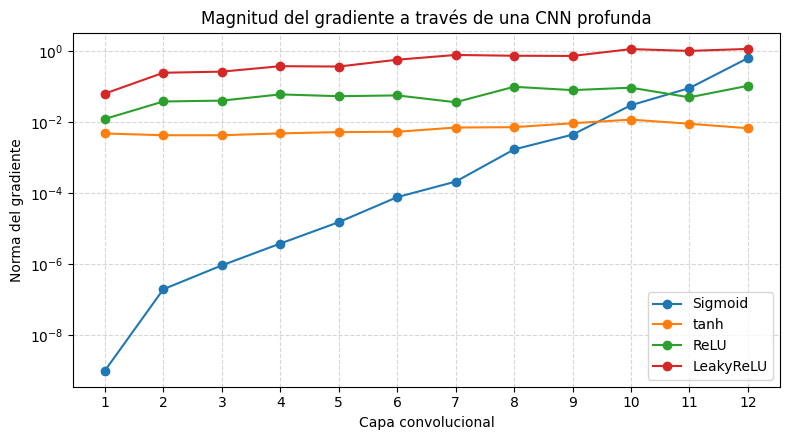

In [3]:
layer_numbers = np.arange(1, 13)

plt.figure(figsize=(8, 4.5))
plt.plot(layer_numbers, sigmoid_gradient_norms, marker="o", label="Sigmoid")
plt.plot(layer_numbers, tanh_gradient_norms, marker="o", label="tanh")
plt.plot(layer_numbers, relu_gradient_norms, marker="o", label="ReLU")
plt.plot(layer_numbers, leaky_relu_gradient_norms, marker="o", label="LeakyReLU")
plt.yscale("log")
plt.title("Magnitud del gradiente a través de una CNN profunda")
plt.xlabel("Capa convolucional")
plt.ylabel("Norma del gradiente")
plt.xticks(layer_numbers)
plt.grid(True, which="both", linestyle="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()